In [1]:
import moabb
from moabb.datasets import *
from moabb.evaluations import CrossSubjectEvaluation
from moabb.paradigms import P300
from hoda import HODA
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.1, fmax=sfreq/2)
datasets = [
    BNCI2014008(),
    #BNCI2014009()
    #EPFLP300()
]
evaluation = CrossSubjectEvaluation(
    paradigm=paradigm, datasets=datasets,
    suffix="examples", overwrite=True,
)

In [3]:
pipelines = dict()

pipelines['tHODA+LDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(max_iter=200, tol=1e-6, rank=(5,5), shrinkage='oas', toeplitz=(1,)),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
)


class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels, data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)

pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)

In [4]:
#import tensorly as tl
#try:
#    tl.set_backend('jax')
#except AttributeError:
#    tl.set_backend('jax')

In [5]:
results = evaluation.process(pipelines)

008-2014-CrossSubject: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [02:25<00:00, 18.20s/it]


In [6]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.756025,0.437380,29400.0,1,session_0,8,1,008-2014,tLDA
1,0.743108,0.451459,29400.0,2,session_0,8,1,008-2014,tLDA
2,0.838387,0.446151,29400.0,3,session_0,8,1,008-2014,tLDA
3,0.751855,0.462298,29400.0,4,session_0,8,1,008-2014,tLDA
4,0.728711,0.483280,29400.0,5,session_0,8,1,008-2014,tLDA
5,0.780513,0.469536,29400.0,6,session_0,8,1,008-2014,tLDA
6,0.801938,0.485574,29400.0,7,session_0,8,1,008-2014,tLDA
7,0.841636,0.488832,29400.0,8,session_0,8,1,008-2014,tLDA
8,0.757488,10.103993,29400.0,1,session_0,8,1,008-2014,tHODA+LDA
9,0.745909,16.505257,29400.0,2,session_0,8,1,008-2014,tHODA+LDA


/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


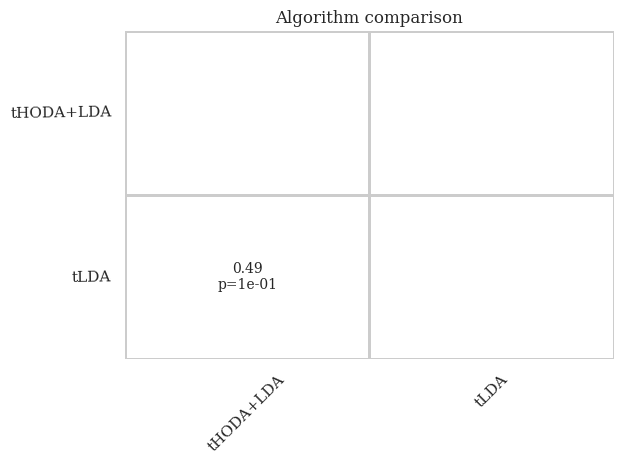

In [7]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

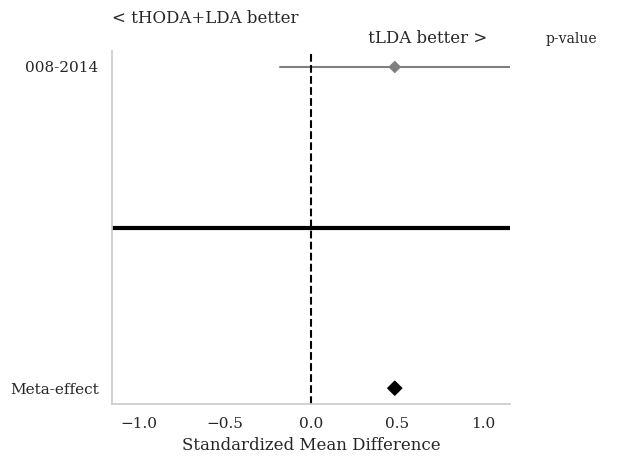

In [8]:
_=meta_analysis_plot(stats, "tLDA", "tHODA+LDA")

/home/arne/.virtualenvs/hoda-venv/lib/python3.10/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


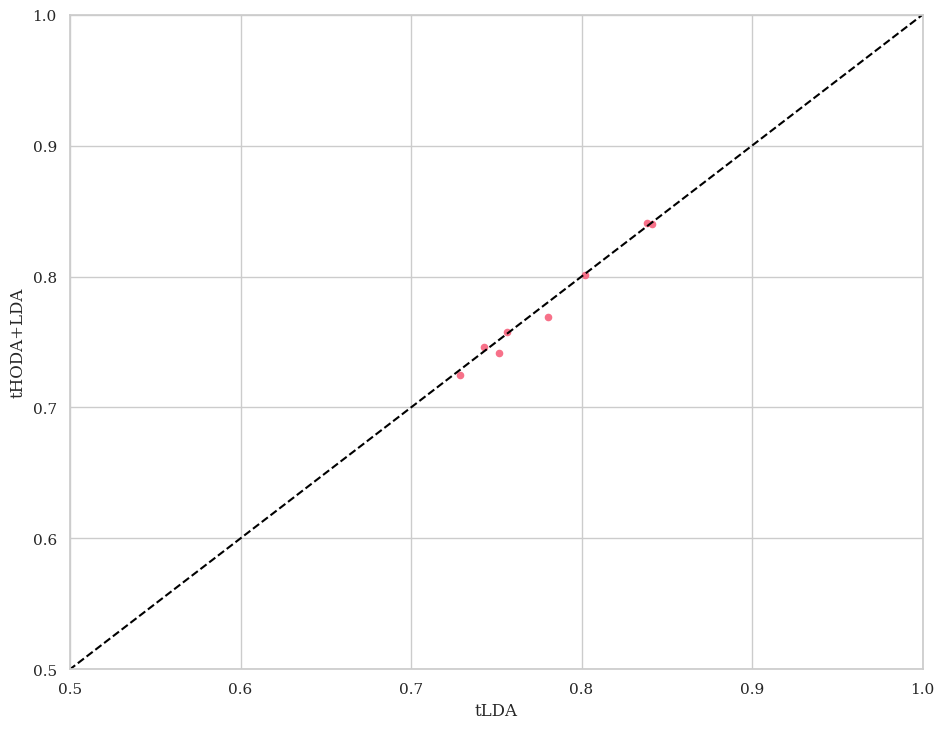

In [9]:
_=paired_plot(results, "tLDA", "tHODA+LDA")